#  Telco Customer Churn Analysis
## Notebook 2 — Exploratory Data Analysis (EDA)

---
**Input:** `telco_churn_cleaned.csv` (output of Notebook 1)  
**Tools:** Python · Pandas · Matplotlib · Seaborn  

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Chart style
RETAINED = '#2E86AB'   
CHURNED  = '#E84855'   
ACCENT   = '#F4A261'   
BG       = '#F8F9FA'  
GREY     = '#6C757D'  

# Global font sizes
plt.rcParams.update({
    'font.family'   : 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [12]:
# Load cleaned data
df = pd.read_csv('../data/telco_churn_cleaned.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Churn rate    : {(df["Churn"]=="Yes").mean()*100:.2f}%')
print(f'Columns       : {list(df.columns)}')

Dataset loaded: 7,043 rows × 28 columns
Churn rate    : 26.54%
Columns       : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'SeniorCitizen_enc', 'Partner_enc', 'Dependents_enc', 'PhoneService_enc', 'PaperlessBilling_enc', 'Churn_enc']


## 1. Overall Churn Distribution — The Business Baseline

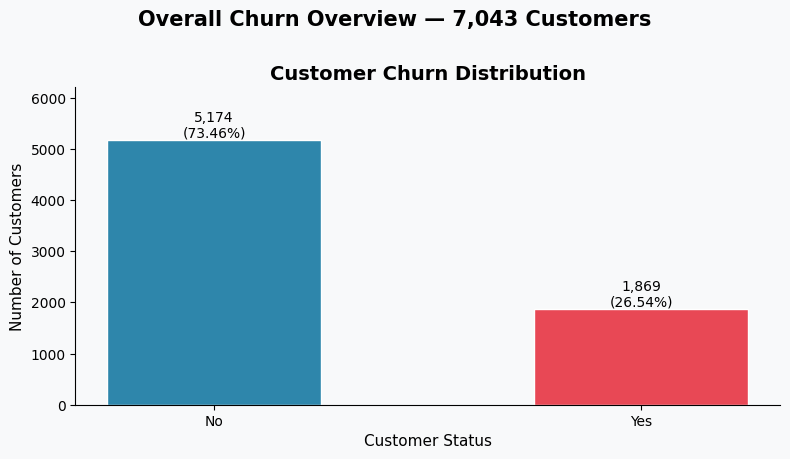

In [13]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
total = len(df)

fig, ax = plt.subplots(figsize=(8,4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.bar(
    churn_counts.index,
    churn_counts.values,
    color=[RETAINED, CHURNED],
    width=0.5,
    edgecolor='white',
    linewidth=1
)

# Labels
ax.set_title('Customer Churn Distribution', fontweight='bold')
ax.set_xlabel('Customer Status')
ax.set_ylim(0, 6200)
ax.set_ylabel('Number of Customers')
ax.spines[['top', 'right']].set_visible(False)

# Add count + percentage
for i, v in enumerate(churn_counts.values):
    pct = (v / total) * 100
    ax.text(i, v + (0.01 * max(churn_counts.values)),
            f'{v:,}\n({pct:.2f}%)',
            ha='center')

plt.xticks(rotation=0)
plt.suptitle('Overall Churn Overview — 7,043 Customers',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Insight:
The company is losing 1,869 out of 7,043 customers, a churn rate of 26.54%, which is 6.5 points above the telecom industry average of 20%. In simple terms, 1 in every 4 customers is walking out the door. Such a high churn rate indicates a significant retention issue and highlights the need to identify key factors driving customer churn.

## 2. Churn by Contract Type


--- Contract Type Summary ---
Month-to-month       → Churn: 42.71% | Customers: 55.0%
One year             → Churn: 11.27% | Customers: 20.9%
Two year             → Churn: 2.83% | Customers: 24.1%


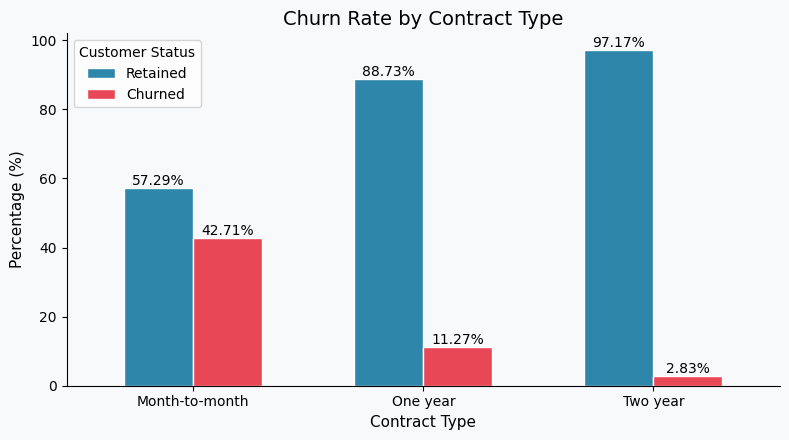

In [14]:
# Churn % by contract type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.columns = ['Retained', 'Churned']

contract_order = ['Month-to-month', 'One year', 'Two year']
contract_churn = contract_churn.loc[contract_order]

# Customer distribution %
contract_dist = df['Contract'].value_counts(normalize=True) * 100
contract_dist = contract_dist.reindex(contract_order)

# Summary output
print("\n--- Contract Type Summary ---")
for i in contract_order:
    print(f"{i:<20} → Churn: {contract_churn.loc[i,'Churned']:.2f}% | Customers: {contract_dist.loc[i]:.1f}%")
    
# Plot 
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
contract_churn.plot(
    kind='bar',
    ax=ax,
    color=[RETAINED, CHURNED],
    width=0.6,
    edgecolor='white',
    linewidth=1
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
ax.spines[['top', 'right']].set_visible(False)
plt.legend(title='Customer Status')

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

#### Insight:
Contract type shows a strong relationship with churn. Month-to-month customers have a churn rate of 42.71%, while two-year contract customers have a much lower churn rate of 2.83%. This indicates that customers with longer-term commitments are significantly more likely to stay. Additionally, a large portion of customers are on month-to-month contracts, making this segment a key area to focus on for improving retention.

## 3. Churn by Tenure Group


--- Tenure Summary ---

Median tenure of churned customers: 10 months

0-12 Months     → Churn: 47.44% | Customers: 31.0%
13-24 Months    → Churn: 28.71% | Customers: 14.5%
25-48 Months    → Churn: 20.39% | Customers: 22.6%
49-72 Months    → Churn: 9.51% | Customers: 31.8%


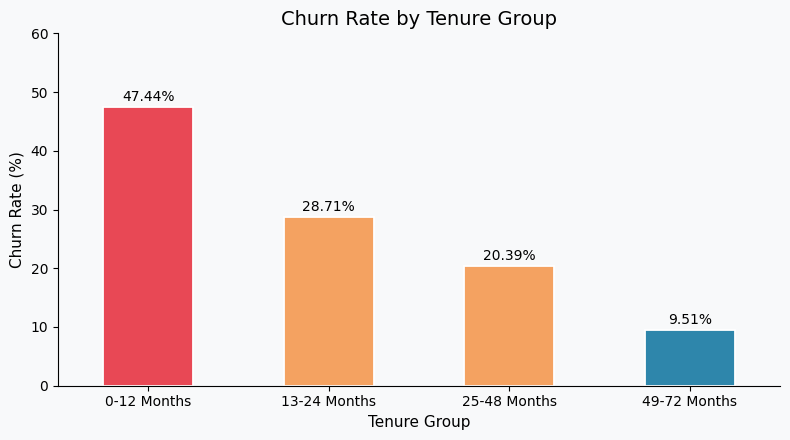

In [20]:
# Churn % by tenure group
tenure_churn = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100

tenure_order = ['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months']
tenure_churn = tenure_churn.loc[tenure_order]

# Customer distribution %
tenure_dist = df['tenure_group'].value_counts(normalize=True) * 100
tenure_dist = tenure_dist.reindex(tenure_order)

colors = [CHURNED if r > 30 else ACCENT if r > 20 else RETAINED
          for r in tenure_churn['Yes']]

print("\n--- Tenure Summary ---")
median_tenure = df[df['Churn'] == 'Yes']['tenure'].median()
print(f"\nMedian tenure of churned customers: {median_tenure:.0f} months\n")
for grp in tenure_order:
    print(f"{grp:<15} → Churn: {tenure_churn.loc[grp,'Yes']:.2f}% | Customers: {tenure_dist.loc[grp]:.1f}%")
    
# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
tenure_churn['Yes'].plot(
    kind='bar',
    color=colors,
    ax=ax,
    width=0.5,
    edgecolor='white',
    linewidth=1.3)

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, 60)

# Labels
for i, v in enumerate(tenure_churn['Yes']):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

#### Insight:
Churn is heavily concentrated in the early stage of the customer lifecycle, with 47.4% of customers leaving within the first 12 months. The median tenure of churned customers is around 10 months, indicating that most customers leave shortly after joining. In contrast, churn drops significantly for long-tenure customers, reaching around 9.5% after 4 years. This suggests that improving the early customer experience and onboarding process could significantly improve overall retention.

## 4. Monthly Charges

Churned  → Mean: $74.44 | Median: $79.65
Retained → Mean: $61.27 | Median: $64.43
Mean difference: $13.18


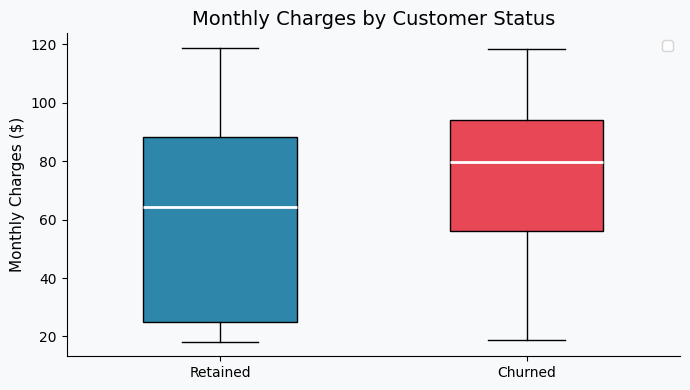

In [21]:
grp = {s: df[df['Churn'] == s]['MonthlyCharges'] for s in ['Yes', 'No']}
diff = grp['Yes'].mean() - grp['No'].mean()

print(f"Churned  → Mean: ${grp['Yes'].mean():.2f} | Median: ${grp['Yes'].median():.2f}")
print(f"Retained → Mean: ${grp['No'].mean():.2f} | Median: ${grp['No'].median():.2f}")
print(f"Mean difference: ${diff:.2f}")

fig, ax = plt.subplots(figsize=(7,4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bp = ax.boxplot(
    [grp['No'], grp['Yes']],
    tick_labels=['Retained', 'Churned'],
    patch_artist=True,
    widths=0.5,
    medianprops={'color': 'white', 'linewidth': 2}
)

for box, color in zip(bp['boxes'], [RETAINED, CHURNED]):
    box.set_facecolor(color)

ax.set_title('Monthly Charges by Customer Status')
ax.set_ylabel('Monthly Charges ($)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Insight:
Churned customers pay an average of \\\$74.44 per month compared to \\\$61.27 for retained customers — about $13 more. This indicates that higher-paying customers are more likely to churn. This suggests that pricing or perceived value may be influencing churn, and should be investigated further.

## 5. Churn by Internet Service


--- Internet Service Summary ---
No Internet     → Churn: 7.4% | Avg charge: $21.08
DSL             → Churn: 19.0% | Avg charge: $58.10
Fiber Optic     → Churn: 41.9% | Avg charge: $91.50


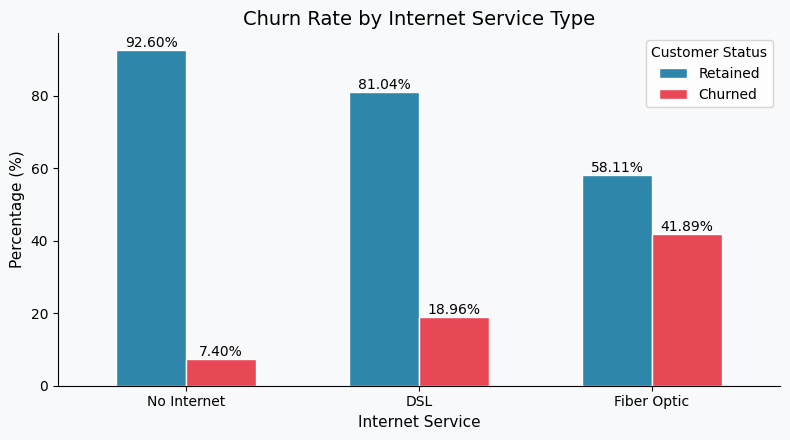

In [22]:
# Churn % by internet service
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

order = ['No', 'DSL', 'Fiber optic']
internet_churn = internet_churn.loc[order]

# Rename labels
internet_churn.columns = ['Retained', 'Churned']
x_labels = ['No Internet', 'DSL', 'Fiber Optic']
internet_churn.index = x_labels

# Avg charges
avg_charges = df.groupby('InternetService')['MonthlyCharges'].mean().round(2)

# Print summary
print("\n--- Internet Service Summary ---")
for i, label in zip(order, x_labels):
    print(f"{label:<15} → Churn: {internet_churn.loc[label,'Churned']:.1f}% | Avg charge: ${avg_charges[i]:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
internet_churn.plot(
    kind='bar',
    ax=ax,
    color=[RETAINED, CHURNED],
    width=0.6,
    edgecolor='white',
    linewidth=1
)

plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
ax.spines[['top', 'right']].set_visible(False)
plt.legend(title='Customer Status')

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

#### Insight:
Fiber optic customers have the highest churn rate at 41.9%, significantly higher than DSL customers at 19%. At the same time, fiber customers also pay higher monthly charges on average. This indicates that higher-cost services are associated with higher churn. Since a large portion of customers are on fiber plans, this segment contributes significantly to overall churn and should be a key focus area for further investigation.

## 6. Churn by Add-on Services


--- Add-on Impact on Churn ---
Online Security      → With: 14.61% | Without: 41.77% (+27.16%)
Tech Support         → With: 15.17% | Without: 41.64% (+26.47%)
Online Backup        → With: 21.53% | Without: 39.93% (+18.40%)
Device Protection    → With: 22.50% | Without: 39.13% (+16.63%)


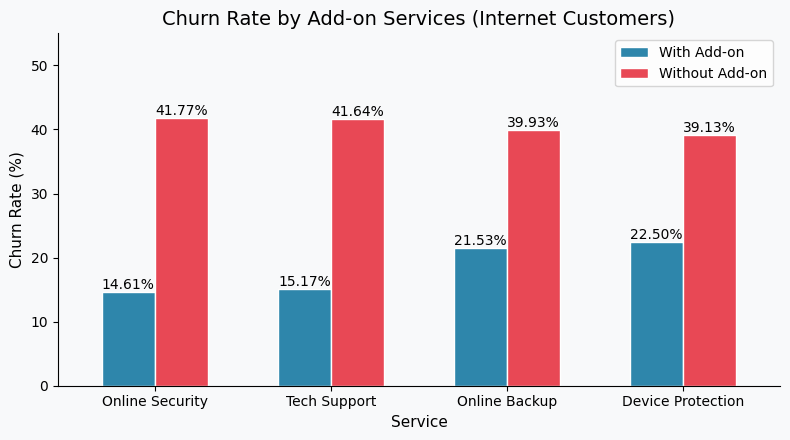

In [23]:
# Filter internet users only
internet_df = df[df['InternetService'] != 'No']

addon_cols = ['OnlineSecurity','TechSupport','OnlineBackup','DeviceProtection']
x_labels   = ['Online Security','Tech Support','Online Backup','Device Protection']

# Compute churn %
addon_churn = {}
for col in addon_cols:
    temp = pd.crosstab(internet_df[col], internet_df['Churn'], normalize='index') * 100
    addon_churn[col] = temp.loc[['Yes','No'], 'Yes']

addon_churn = pd.DataFrame(addon_churn).T
addon_churn.columns = ['With Add-on', 'Without Add-on']
addon_churn.index = x_labels

# Print summary
print("\n--- Add-on Impact on Churn ---")
for i in addon_churn.index:
    with_rate = addon_churn.loc[i, 'With Add-on']
    without_rate = addon_churn.loc[i, 'Without Add-on']
    diff = without_rate - with_rate
    
    print(f"{i:<20} → With: {with_rate:.2f}% | Without: {without_rate:.2f}% ({diff:+.2f}%)")

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
addon_churn.plot(
    kind='bar',
    ax=ax,
    color=[RETAINED, CHURNED],
    width=0.6,
    edgecolor='white',
    linewidth=1
)

plt.title('Churn Rate by Add-on Services (Internet Customers)')
plt.xlabel('Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0,55)
plt.legend()

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

#### Insight:
Among internet customers, those without Online Security have a churn rate of 41.8%, compared to just 14.6% for those with it — a difference of over 27 percentage points. A similar pattern is observed for Tech Support, Online Backup, and Device Protection. This indicates a strong association between add-on service adoption and lower churn. Encouraging customers to adopt these services, especially early in their lifecycle, could be an effective strategy to improve retention.

## 7. Churn by Payment Method


--- Payment Method Summary ---
Credit card (automatic)             → 15.2% (Auto-pay)
Bank transfer (automatic)           → 16.7% (Auto-pay)
Mailed check                        → 19.1%
Electronic check                    → 45.3%


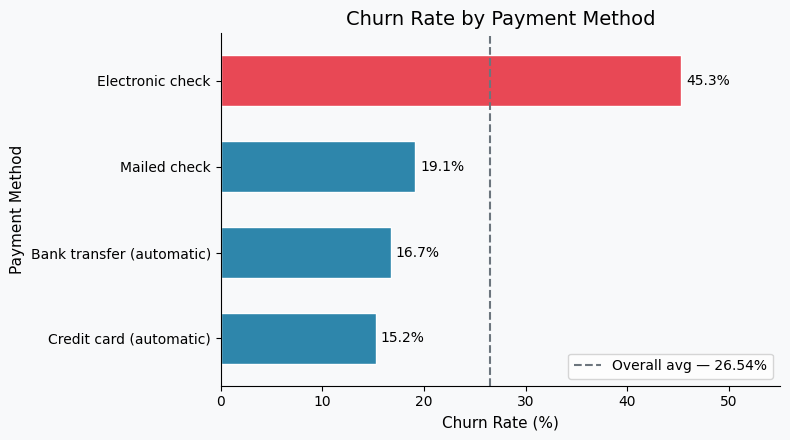

In [24]:
# Overall churn
avg_churn = (df['Churn'] == 'Yes').mean() * 100

# Churn % by payment method
pay_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
pay_churn = pay_churn.sort_values('Yes')

# Summary
print("\n--- Payment Method Summary ---")
for i in pay_churn.index:
    tag = " (Auto-pay)" if "automatic" in i else ""
    print(f"{i:<35} → {pay_churn.loc[i,'Yes']:.1f}%{tag}")
    
# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
pay_churn['Yes'].plot(
    kind='barh',
    ax=ax,
    color=[CHURNED if v > avg_churn else RETAINED for v in pay_churn['Yes']],
    width=0.6,
    edgecolor='white',
    linewidth=1,
    legend=False
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')

# Labels
for i, v in enumerate(pay_churn['Yes']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')

# ✅ Average line + legend (correct way)
line = ax.axvline(avg_churn, linestyle='--', color=GREY,
           label=f'Overall avg — {avg_churn:.2f}%')
ax.legend(handles=[line], loc='lower right', fontsize=10)


ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0,55)
plt.tight_layout()
plt.show()

#### Insight:
Customers paying by electronic check have a significantly higher churn rate at 45.3%, compared to around 15–17% for customers using automatic payment methods. This indicates a strong association between payment method and churn. Customers using auto-pay show much lower churn, suggesting that encouraging adoption of automatic payment methods could be an effective strategy to improve retention.

## 8. Revenue at Risk

Monthly revenue : $456,117
Monthly lost: $139,131 (30.5%)

Annual revenue : $5,473,399
Annual lost: $1,669,570
Fiber optic segment loss: $114,300/month (82.2% of total)


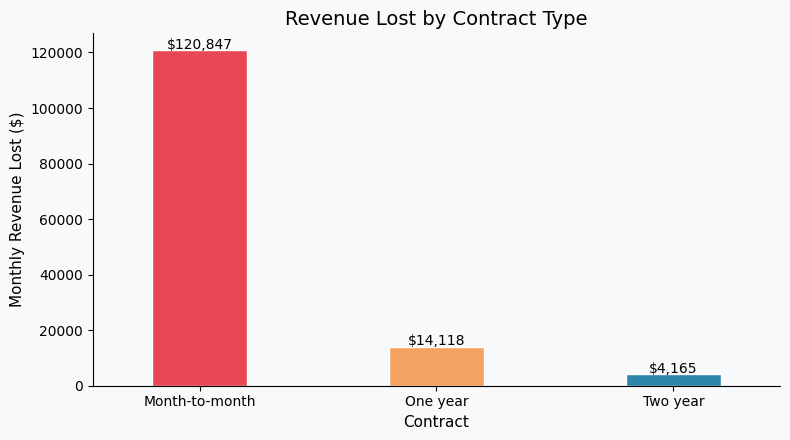

In [25]:
# Revenue calculations
total = df['MonthlyCharges'].sum()
at_risk = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()

print(f"Monthly revenue : ${total:,.0f}")
print(f"Monthly lost: ${at_risk:,.0f} ({at_risk/total*100:.1f}%)")
print(f"\nAnnual revenue : ${total*12:,.0f}")
print(f"Annual lost: ${at_risk*12:,.0f}")
fiber_loss = df[(df['InternetService']=='Fiber optic') & 
                (df['Churn']=='Yes')]['MonthlyCharges'].sum()
print(f"Fiber optic segment loss: ${fiber_loss:,.0f}/month ({fiber_loss/at_risk*100:.1f}% of total)")

# Revenue lost by contract
rc = df[df['Churn']=='Yes'].groupby('Contract')['MonthlyCharges'].sum()

# Plot
fig, ax = plt.subplots(figsize=(8,4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

rc.plot(kind='bar', 
        color=[CHURNED, ACCENT, RETAINED], 
        ax=ax,
        width=0.4,
        edgecolor='white',
        linewidth=1)

plt.title('Revenue Lost by Contract Type')
plt.ylabel('Monthly Revenue Lost ($)')
plt.xticks(rotation=0)

# Labels
for i, v in enumerate(rc):
    ax.text(i, v + 500, f'${v:,.0f}', ha='center')

ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Insight:
The total monthly revenue is \\\$456,117, of which \\\$139,131 — 30.5% — comes from 
customers who have already churned. Annualised, that is $1.67 million in lost revenue 
every year. Month-to-month customers alone drive 86.9% of that loss (\\\$120,847 per month), 
despite being 55% of the base. Fixing month-to-month churn is not just a retention 
initiative — it is the single highest-ROI financial action available to this business.

## 9. Correlation Heatmap

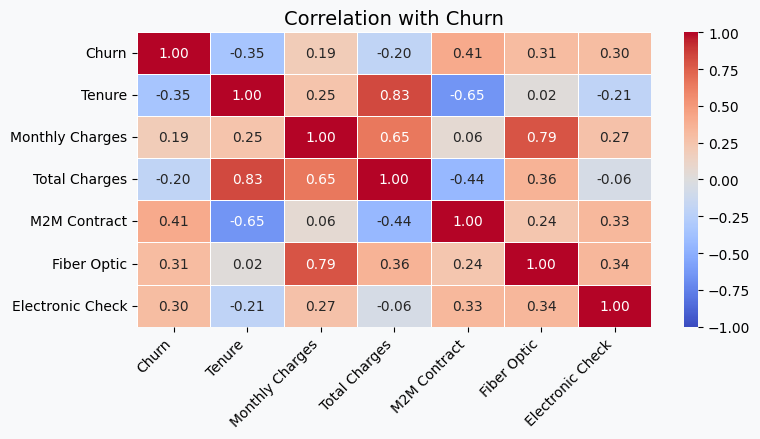

In [26]:
# Select key features
df['Contract_M2M'] = (df['Contract'] == 'Month-to-month').astype(int)
df['Fiber_Optic']  = (df['InternetService'] == 'Fiber optic').astype(int)
df['Elec_Check']   = (df['PaymentMethod'] == 'Electronic check').astype(int)
cols = ['Churn_enc','tenure','MonthlyCharges','TotalCharges',
        'Contract_M2M','Fiber_Optic','Elec_Check']
labels = ['Churn','Tenure','Monthly Charges','Total Charges',
          'M2M Contract','Fiber Optic','Electronic Check']

corr = df[cols].corr().round(2)
corr.columns = corr.index = labels

# Plot
fig, ax = plt.subplots(figsize=(8,4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
sns.heatmap(corr, annot=True, fmt='.2f', # add fmt='.2f'
            cmap='coolwarm', center=0,
            vmin=-1, vmax=1,             # add full scale
            linewidths=0.5, linecolor='white')
plt.xticks(rotation=45, ha='right')      # add rotation
plt.yticks(rotation=0)
plt.title('Correlation with Churn')
plt.tight_layout()
plt.show()

#### Insight:
The correlation analysis brings together the key patterns observed earlier. Month-to-month contracts show the strongest positive relationship with churn at +0.41, while tenure shows a strong negative relationship at -0.35, indicating that longer-term customers are less likely to churn. Fiber optic service and electronic check payments also show positive correlations with churn, aligning with earlier findings. Overall, these patterns suggest a consistent profile of higher-risk customers — those who are newer, on month-to-month contracts, using fiber optic services, paying via electronic check, and not using add-on services.

## 10. EDA Summary — Key Findings & Business Recommendations

In [27]:
print(f"""
 BASELINE
  • 7,043 customers analysed
  • Churn rate        : 26.54% (1,869 customers)
  • Industry average  : ~20%   → this company is 6.5 percentage points above the industry average
  • Monthly rev lost  : $139,131
  • Annual rev at risk: $1,669,570

 TOP 5 FINDINGS
  1. CONTRACT TYPE is the #1 churn driver
     Month-to-month: 42.7% churn vs Two-year: 2.8% — a 15× gap

  2. FIRST 12 MONTHS is the critical retention window
     47.4% of 0–12 month customers churn
     Drops to 9.5% for 49–72 month customers

  3. FIBER OPTIC PARADOX — premium product, highest churn
     Fiber optic: 41.9% churn vs DSL: 19.0%
     Despite paying $91.55/month avg (vs $58.10 for DSL)

  4. ADD-ON SERVICES nearly triple retention
     No OnlineSecurity: 41.8% churn | With: 14.6%
     No TechSupport: 41.6% churn    | With: 15.2%

  5. ELECTRONIC CHECK payers are 3× more likely to churn
     Electronic check: 45.3% vs Auto-pay: ~15–17%

  6. HIGHEST-RISK SEGMENT
     M2M + Fiber Optic + Electronic Check + Tenure ≤ 12 months
     → 631 customers | 71.2% churn rate | $37,166 monthly loss

 TOP 3 BUSINESS RECOMMENDATIONS
  1. Launch contract upgrade campaign for M2M customers
     Target: 3,875 M2M customers | Offer: 1-month discount for annual switch

  2. Bundle OnlineSecurity + TechSupport free for first 3 months
     Focus on: fiber optic + 0–12 month customers

  3. Auto-pay migration incentive: $5/month discount
     Target: 2,365 electronic check payers on M2M contracts
""")


 BASELINE
  • 7,043 customers analysed
  • Churn rate        : 26.54% (1,869 customers)
  • Industry average  : ~20%   → this company is 6.5 percentage points above the industry average
  • Monthly rev lost  : $139,131
  • Annual rev at risk: $1,669,570

 TOP 5 FINDINGS
  1. CONTRACT TYPE is the #1 churn driver
     Month-to-month: 42.7% churn vs Two-year: 2.8% — a 15× gap

  2. FIRST 12 MONTHS is the critical retention window
     47.4% of 0–12 month customers churn
     Drops to 9.5% for 49–72 month customers

  3. FIBER OPTIC PARADOX — premium product, highest churn
     Fiber optic: 41.9% churn vs DSL: 19.0%
     Despite paying $91.55/month avg (vs $58.10 for DSL)

  4. ADD-ON SERVICES nearly triple retention
     No OnlineSecurity: 41.8% churn | With: 14.6%
     No TechSupport: 41.6% churn    | With: 15.2%

  5. ELECTRONIC CHECK payers are 3× more likely to churn
     Electronic check: 45.3% vs Auto-pay: ~15–17%

  6. HIGHEST-RISK SEGMENT
     M2M + Fiber Optic + Electronic Check